# 4.  Reason from multiple evidence 
1. Take the burglary example from the lecture as a basis and implement a Python class that 
enables to reason from any number of pieces of evidence. Provide appropriate methods to 
define the number of evidence pieces and input the required numbers. Ensure proper 
operation when some of the pieces of evidence are not present. 
2. Play with the class, plot output for different combinations of inputs. 
3. Going back to the example, consider situation when the alarm is not silent – it blares horn 
and flashes light when it goes off. Can computations still be performed in the same manner? 
Explain.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Take the burglary example from the lecture as a basis and implement a Python class that enables to reason from any number of pieces of evidence. Provide appropriate methods to define the number of evidence pieces and input the required numbers. Ensure proper operation when some of the pieces of evidence are not present. 

In [13]:
class Burglary: # klasa ma mozliwosc wnioskowania z dowolnej liczby zrodel danych (milion parametrow)
    def __init__(self, p_i):
        self.p_i = p_i # probability of intrusion
        self.evidence = {}
                
    def add_evidence(self, name, p_given_i, p_given_not_i):
        self.evidence[name] = {
            'p_given_i': p_given_i, # P(E|I)
            'p_given_not_i': p_given_not_i #P(E|¬I)
        }
        
    def infer(self, observations):
        """
        observations: dict where each key is the evidence name and value is:
                        True  -> evidence occurred
                        False -> evidence did not occur
                        None  -> unknown, skip
        Returns: P(I|Observations)
        """
        p_obs_given_i = 1.0
        p_obs_given_not_i = 1.0
        
        for ev_name, info in self.evidence.items():
            if ev_name not in observations or observations[ev_name] is None:
                continue # skip missing evidence
            
            if observations[ev_name]: # evidence present
                p_obs_given_i *= info['p_given_i'] # P(E|I) * previous [ P(E1|I) * P(E2|I) * ... ]
                p_obs_given_not_i *= info['p_given_not_i'] # P(E|¬I) * previous

            else: # evidence absent
                p_obs_given_i *= (1 - info['p_given_i']) # P(¬E|I) * previous
                p_obs_given_not_i *= (1 - info['p_given_not_i']) # P(¬E|¬I) * previous

        # Bayes theorem
        numerator = p_obs_given_i * self.p_i
        denominator = numerator + p_obs_given_not_i * (1 - self.p_i) # P(¬I)
        
        return numerator / denominator

In [10]:
model = Burglary(p_i=0.002)

model.add_evidence("alarm", p_given_i=0.8, p_given_not_i=0.01)
model.add_evidence("dog", p_given_i=0.98, p_given_not_i=0.5)

In [11]:
scenarios = {
    "1. Alarm only": {"alarm": True, "dog": None},
    "2. Alarm + dog": {"alarm": True, "dog": True},
    "3. Alarm + no dog": {"alarm": True, "dog": False},
    "4. Dog only": {"alarm": None, "dog": True},
    "5. Missing evidence": {"alarm": None, "dog": None}
}

In [12]:
for desc, obs in scenarios.items():
    p = model.infer(obs)
    print(f"{desc:<20}: P(I|obs) = {p:.5f}")

1. Alarm only       : P(I|obs) = 0.13817
2. Alarm + dog      : P(I|obs) = 0.23910
3. Alarm + no dog   : P(I|obs) = 0.00637
4. Dog only         : P(I|obs) = 0.00391
5. Missing evidence : P(I|obs) = 0.00200


### 2. Play with the class, plot output for different combinations of inputs. 


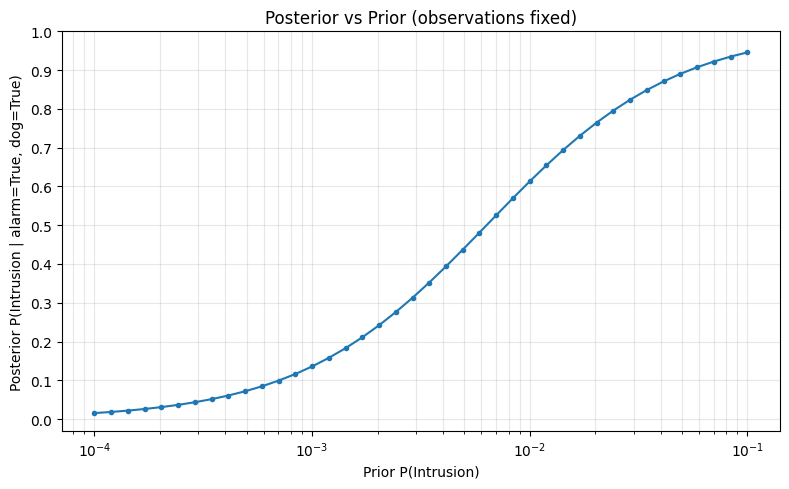

In [ ]:
evs = model.evidence

obs_all_true = {name: True for name in evs.keys()}

priors = np.logspace(-4, -1, 40)  # from 0.0001 to 0.1
post_priors = []
for pr in priors:
    m = Burglary(p_i=pr)
    for name, info in evs.items():
        m.add_evidence(name, info['p_given_i'], info['p_given_not_i'])
    post_priors.append(m.infer(obs_all_true))

plt.figure(figsize=(8,5))
plt.semilogx(priors, post_priors, marker='o', ms=3)
plt.xlabel('Prior P(Intrusion)')
plt.ylabel('Posterior P(Intrusion | alarm=True, dog=True)')
plt.yticks(np.linspace(0, 1, 11))
plt.title('Posterior vs Prior (observations fixed)')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

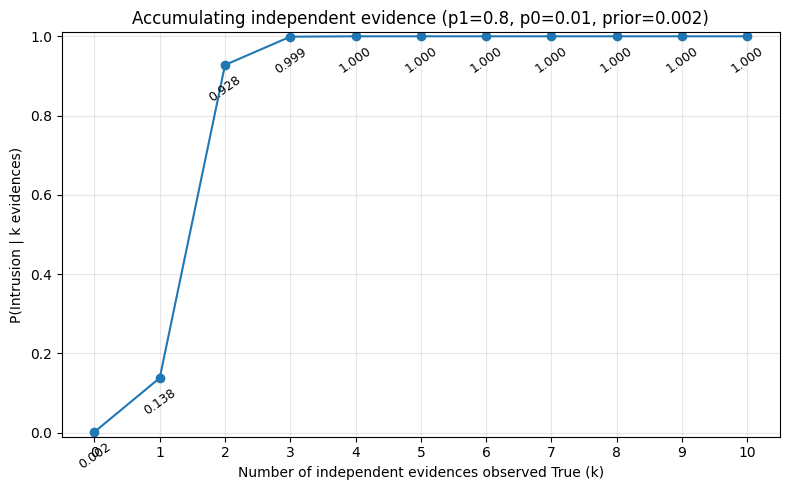

In [37]:
prior = 0.002
p1, p0 = 0.8, 0.01
ks = np.arange(0, 11)
posters_k = []
for k in ks:
    m = Burglary(p_i=prior)
    for i in range(k):
        m.add_evidence(f's{i+1}', p1, p0)
    obs = {f's{i+1}': True for i in range(k)}
    if k == 0:
        # No evidence -> posterior equals prior
        posters_k.append(prior)
    else:
        posters_k.append(m.infer(obs))

plt.figure(figsize=(8,5))
plt.plot(ks, posters_k, marker='o')
plt.xlabel('Number of independent evidences observed True (k)')
plt.ylabel('P(Intrusion | k evidences)')
plt.title('Accumulating independent evidence (p1=0.8, p0=0.01, prior=0.002)')
plt.grid(True, alpha=0.3)
plt.ylim(-0.01, 1.01)
plt.xticks(ks)

for x, y in zip(ks, posters_k):
    plt.text(x, y - 0.1, f"{y:.3f}",
             ha='center', va='bottom',
             rotation=35,  # <-- nachylenie napisu
             fontsize=9)

plt.tight_layout()
plt.show()

### 3. Going back to the example, consider situation when the alarm is not silent – it blares horn and flashes light when it goes off. Can computations still be performed in the same manner? Explain.

The calculations are not the same because, when the pieces of evidence are dependent, we cannot simply multiply the P(E|I) terms and then multiply once by P(I). The evidence items are not independent, so the factorization P(A, B | I) = P(A | I) P(B | I) **is not** valid.

In such a case, you would need to use the joint probabilities P(Horn and Light | I) and P(Horn and Light | ¬I). In that case, you would need to know the values of these probabilities, which would make the calculations more difficult.